In [1]:
import fire
import pickle
import json
import pandas as pd
import matplotlib.pyplot as plt
from ray import tune
from pytagi import metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    Optimizer,
    SKF,
    plot_data,
    plot_prediction,
    plot_skf_states,
    plot_states,
)
from canari.component import LocalTrend, LocalAcceleration, LstmNetwork, WhiteNoise

/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:395: SyntaxWarning: invalid escape sequence '\p'
  [r"$\mu$", f"$\pm{num_std}\sigma$"], loc=legend_location, ncol=2
/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:395: SyntaxWarning: invalid escape sequence '\s'
  [r"$\mu$", f"$\pm{num_std}\sigma$"], loc=legend_location, ncol=2
/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:537: SyntaxWarning: invalid escape sequence '\p'
  [r"$\mu$", f"$\pm{num_std}\sigma$", r"$y$"],
/Users/vuongdai/GitHub/canari/src/canari/data_visualization.py:537: SyntaxWarning: invalid escape sequence '\s'
  [r"$\mu$", f"$\pm{num_std}\sigma$", r"$y$"],


In [2]:
######### Data processing #########
# Read data
data_file = "/Users/vuongdai/Desktop/backup_canari/benchmark/data_20260114/benchmark_data/test_4_data.csv"
df = pd.read_csv(data_file, skiprows=0, delimiter=",")
date_time = pd.to_datetime(df["date"])
df = df.drop(["date"], axis=1)
# df = df.drop(["date","Var3_1","Var3_2","Var3_3"], axis=1)
df.index = date_time
df.index.name = "date_time"
# Data pre-processing
df = DataProcess.add_lagged_columns(df, [0,4,4,4])
output_col = [0]
data_processor = DataProcess(
    data=df,
    time_covariates=["week_of_year"],
    train_split=0.23,
    validation_split=0.07,
    output_col=output_col,
)
train_data, validation_data, _, all_data = data_processor.get_splits()

In [3]:
def model_with_parameters(param):
    model = Model(
        LocalTrend(),
        LstmNetwork(
            look_back_len=param["look_back_len"],
            # num_features=2,
            num_features=17,
            num_layer=1,
            num_hidden_unit=50,
            manual_seed=1,
            smoother=False,
        ),
        WhiteNoise(std_error=param["sigma_v"]),
    )

    model.auto_initialize_baseline_states(train_data["y"][0:156])
    mu_validation_preds_optim = None
    std_validation_preds_optim = None
    num_epoch = 50
    for epoch in range(num_epoch):
        mu_validation_preds, std_validation_preds, states = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        mu_validation_preds_unnorm = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[data_processor.output_col],
            data_processor.scale_const_std[data_processor.output_col],
        )

        std_validation_preds_unnorm = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[data_processor.output_col],
        )

        validation_obs = data_processor.get_data("validation").flatten()
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds_unnorm,
            observation=validation_obs,
            std=std_validation_preds_unnorm,
        )
        mse = metric.mse(mu_validation_preds, validation_obs)
        model.early_stopping(
            # evaluate_metric=mse,
            evaluate_metric=-validation_log_lik,
            current_epoch=epoch,
            max_epoch=num_epoch,
        )
        model.metric_optim = model.early_stop_metric

        if epoch == model.optimal_epoch:
            mu_validation_preds_optim = mu_validation_preds.copy()
            std_validation_preds_optim = std_validation_preds.copy()

        if model.stop_training:
            break

    return (
        model,
        mu_validation_preds_optim,
        std_validation_preds_optim,
    )

In [4]:
def skf_with_parameters(skf_param_space, skf_input):
    norm_model = Model.load_dict(skf_input["model_optim_dict"])

    abnorm_model = Model(
        LocalAcceleration(),
        LstmNetwork(),
        WhiteNoise(),
    )
    skf = SKF(
        norm_model=norm_model,
        abnorm_model=abnorm_model,
        std_transition_error=skf_param_space["std_transition_error"],
        norm_to_abnorm_prob=skf_param_space["norm_to_abnorm_prob"],
    )
    skf.save_initial_states()

    num_anomaly = 50
    detection_rate, num_false_alarm = skf.detect_synthetic_anomaly(
        data=train_data,
        num_anomaly=num_anomaly,
        slope_anomaly=skf_param_space["slope"] / 52,
    )

    data_len_year = (
        data_processor.data.index[data_processor.train_end]
        - data_processor.data.index[data_processor.train_start]
    ).days / 365.25

    false_rate_yearly = num_false_alarm / data_len_year
    metric_optim = skf.objective(
        detection_rate, false_rate_yearly, skf_param_space["slope"]
    )

    skf.load_initial_states()
    skf.metric_optim = metric_optim.copy()
    print_metric = {}
    print_metric["detection_rate"] = detection_rate
    print_metric["yearly_false_rate"] = false_rate_yearly
    skf.print_metric = print_metric

    return skf

In [76]:
# Define parameter search space
param_space = {
    "look_back_len": [12, 53],
    "sigma_v": [1e-2, 2e-1],
}
# Define optimizer
model_optimizer = Optimizer(
    model=model_with_parameters,
    param=param_space,
    num_optimization_trial=50,
    mode="min",
)
model_optimizer.optimize()
# Get best model
param = model_optimizer.get_best_param()

# Train best model
model_optim, mu_validation_preds, std_validation_preds = (
    model_with_parameters(param)
)

# Save best model for SKF analysis later
model_optim_dict = model_optim.get_dict(time_step=0)

#  1/50 - Metric: -1.962 - Parameter: {'look_back_len': 33, 'sigma_v': 0.07149935928148268}
#  2/50 - Metric: -11.597 - Parameter: {'look_back_len': 17, 'sigma_v': 0.1554789185045939}
#  3/50 - Metric: -28.087 - Parameter: {'look_back_len': 46, 'sigma_v': 0.03216884094532957}
#  4/50 - Metric: -25.356 - Parameter: {'look_back_len': 41, 'sigma_v': 0.07779204127265629}
#  5/50 - Metric: -23.824 - Parameter: {'look_back_len': 19, 'sigma_v': 0.1682104183976238}
#  6/50 - Metric: -28.740 - Parameter: {'look_back_len': 36, 'sigma_v': 0.14339018061357472}
#  7/50 - Metric: -33.236 - Parameter: {'look_back_len': 37, 'sigma_v': 0.12482218642821973}
#  8/50 - Metric: 23.110 - Parameter: {'look_back_len': 48, 'sigma_v': 0.042342781715163605}
#  9/50 - Metric: -36.556 - Parameter: {'look_back_len': 40, 'sigma_v': 0.13490748322519333}
# 10/50 - Metric: -34.226 - Parameter: {'look_back_len': 45, 'sigma_v': 0.1420219446342573}
# 11/50 - Metric: -27.888 - Parameter: {'look_back_len': 42, 'sigma_v': 0.

2026-10-01 11:47:55,489	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/objective_2026-10-01_11-45-06' in 0.0149s.


# 50/50 - Metric: -35.274 - Parameter: {'look_back_len': 36, 'sigma_v': 0.06608104591901903}
-----
Optimal parameters at trial #41. Best metric: -36.8824. Best print metric: None. Best param: {'look_back_len': 51, 'sigma_v': 0.11602310630554581}.
-----


In [21]:
# # Optimize for skf
skf_param_space = {
    "std_transition_error": [1e-6, 1e-4],
    "norm_to_abnorm_prob": [1e-6, 1e-4],
    "slope": [0.1, 0.6]
}
skf_input = {}
skf_input["model_optim_dict"] = model_optim_dict
skf_optimizer = Optimizer(
    model=skf_with_parameters,
    param=skf_param_space,
    model_input=skf_input,
    num_optimization_trial=80,
    mode="max",
    max_concurrent=4,
)
skf_optimizer.optimize()
# Get parameters
skf_param = skf_optimizer.get_best_param()

skf_optim = skf_with_parameters(skf_param, skf_input)
skf_optim_dict = skf_optim.get_dict()
skf_optim_dict["model_param"] = param
skf_optim_dict["skf_param"] = skf_param
skf_optim_dict["cov_names"] = train_data["cov_names"]
with open("canari_example.pkl", "wb") as f:
    pickle.dump(skf_optim_dict, f)

NameError: name 'model_optim_dict' is not defined

In [5]:
with open("/Users/vuongdai/GitHub/canari/examples/icold22/canari_example.pkl", "rb") as f:
    skf_optim_dict = pickle.load(f)
skf_optim = SKF.load_dict(skf_optim_dict)

In [6]:
######### Detect anomaly #########
print("Model parameters used:", skf_optim_dict["model_param"])
print("SKF model parameters used:", skf_optim_dict["skf_param"])

filter_marginal_abnorm_prob, states = skf_optim.filter(data=all_data)

Model parameters used: {'look_back_len': 51, 'sigma_v': 0.11602310630554581}
SKF model parameters used: {'std_transition_error': 6.961862086454812e-05, 'norm_to_abnorm_prob': 8.27322581178018e-06, 'slope': 0.2773207275880376}


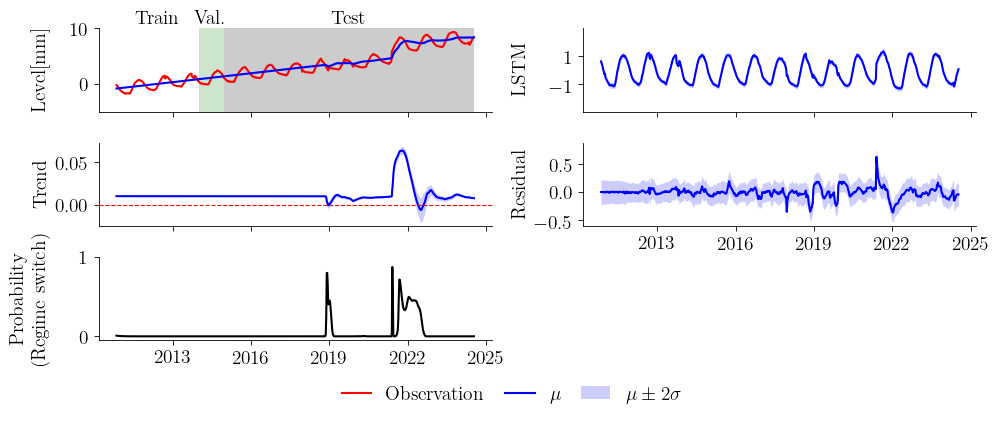

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np

mpl.rcParams.update({
    # Use LaTeX for text rendering — fonts will match your Beamer theme exactly
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",

    # PGF export settings (the .pgf backend ignores text.usetex and uses these)
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{lmodern}",

    # Font sizes: Beamer default body is 11pt
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,

    # Thin lines look better on slides
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.5,

    # No right/top spines (cleaner on slides)
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(3, 2, figsize=(10, 4), sharex=True)

# ===================== Subplot 1: Target model =====================
ax = axes[0, 0]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=True,
    plot_column=output_col,
    plot_nan=False,
    validation_label="Observation",
)
plot_states(
    data_processor=data_processor,
    states=states,
    states_to_plot=["level"],
    num_std=2,
    sub_plot=ax,
    standardization=True,
)
ax.set_ylim(-5, 10)
ax.set_ylabel("Level[mm]")
# ax.set_yticks([0, 1])

# --- Split boundaries on the x-axis ---
time = data_processor.data.index
t_start     = time[0]
t_train_end = time[data_processor.train_end - 1]       # last train point
t_val_end   = time[data_processor.validation_end - 1]  # last validation point
t_end       = time[-1]

# --- Train / validation / test labels above axes[0, 0] ---
ax = axes[0, 0]
trans = ax.get_xaxis_transform()  # x in data (dates), y in axes fraction (0 = bottom, 1 = top)

splits = [
    ("Train",      t_start,     t_train_end),
    ("Val.",       t_train_end, t_val_end),
    ("Test",       t_val_end,   t_end),
]

for label, t0, t1 in splits:
    t_mid = t0 + (t1 - t0) / 2
    ax.text(
        t_mid, 1.02, label,
        transform=trans,
        ha="center", va="bottom",
        fontsize=14,
        clip_on=False,
    )

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ===================== Subplot 2: Trend =====================
ax = axes[1, 0]
plt.sca(ax)
plot_states(
    data_processor=data_processor,
    states=states,
    states_to_plot=["trend"],
    num_std=2,
    sub_plot=ax,
    standardization=True,
)
ax.set_ylabel("Trend")

# ===================== Subplot 3: Prob =====================
ax = axes[2, 0]
plt.sca(ax)
ax.plot(all_data["time"], filter_marginal_abnorm_prob, color="black")
# ax.set_ylabel(r"$\Pr(Regime switch)$")
ax.set_ylabel("Probability \n(Regime switch)", multialignment="center")
ax.set_ylim(-0.05, 1)
ax.set_yticks([0, 1])

# ===================== Subplot 4: LSTM =====================
ax = axes[0, 1]
plt.sca(ax)
plot_states(
    data_processor=data_processor,
    states=states,
    states_to_plot=["lstm"],
    num_std=2,
    sub_plot=ax,
    standardization=True,
)
ax.set_ylabel("LSTM")
ax.set_ylim(-3, 3)
ax.set_yticks([-1, 1])


# ===================== Subplot 5: White noise =====================
ax = axes[1, 1]
plt.sca(ax)
plot_states(
    data_processor=data_processor,
    states=states,
    states_to_plot=["white noise"],
    num_std=2,
    sub_plot=ax,
    standardization=True,
)
ax.set_ylabel("Residual")

# ===================== Subplot 6: Blank =====================
axes[2, 1].axis("off")

# With sharex=True, x tick labels only show on the bottom row.
# Since axes[2, 1] is blank, show the x tick labels on axes[1, 1] instead.
axes[1, 1].tick_params(axis="x", labelbottom=True)

for ax in axes.flat:
    if not ax.axison:  # skip the blank subplot
        continue

    # Remove gridlines (added by plot_states / plot_data)
    ax.grid(False)

    # Keep only left and bottom borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    # x-axis: a major tick every 4 years, labeled by year, no minor ticks
    ax.xaxis.set_major_locator(mdates.YearLocator(base=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mticker.NullLocator())

    # y-axis: no minor ticks
    ax.yaxis.set_minor_locator(mticker.NullLocator())

# ===================== Save =====================
fig.tight_layout(h_pad=0.2, w_pad=1)  # h_pad: vertical gap, w_pad: horizontal gap

# Vertically align y-labels within each column
fig.align_ylabels(axes[:, 0])
fig.align_ylabels(axes[:, 1])

legend_handles = [
    Line2D([0], [0], color="red",  lw=1.5, label="Observation"),
    Line2D([0], [0], color="blue", lw=1.5, label=r"$\mu$"),
    Patch(facecolor="blue",  alpha=0.2, label=r"$\mu \pm 2\sigma$"),
    # Line2D([0], [0], color="black",  lw=1.5, label="probability of regime switch"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.05),   # centered horizontally, just below the figure
    ncol=len(legend_handles),    # all in one row
    frameon=False,
    fontsize=14,
    handlelength=1.5,
    columnspacing=1.0,
)

fig.savefig("canari_example.pdf", bbox_inches="tight")
fig.savefig("canari_example.pgf", bbox_inches="tight")
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.transforms import blended_transform_factory

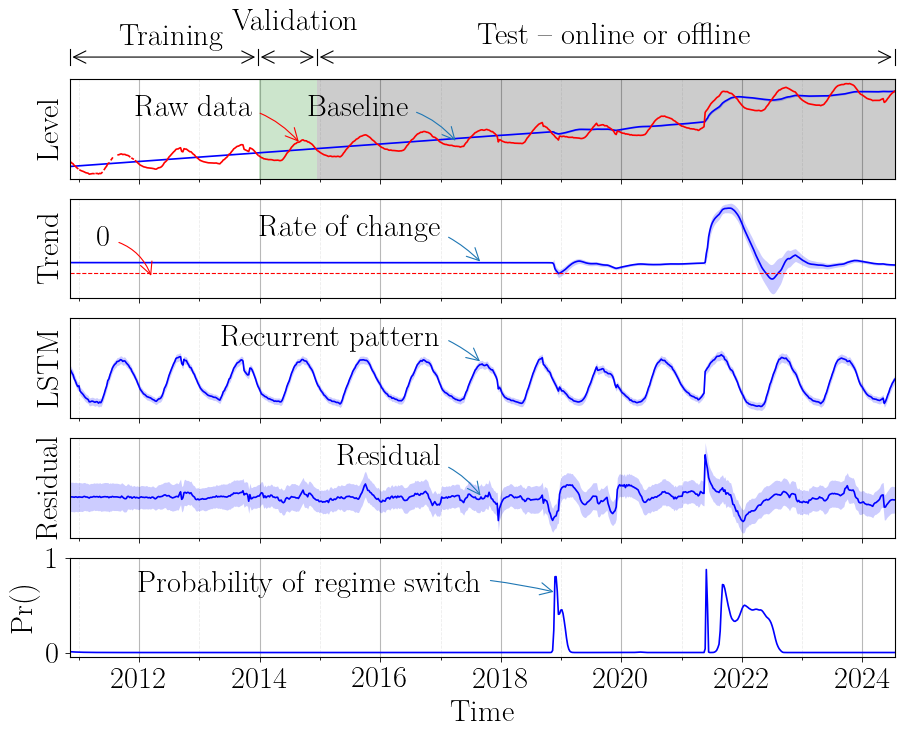

In [9]:
FONT_SIZE = 22          # ~10-12 for a one-column paper figure, ~18-22 for slides
FIG_W, FIG_H = 5, 5  # inches

mpl.rcParams.update({
    "font.size":       FONT_SIZE,
    "axes.labelsize":  FONT_SIZE,
    "axes.titlesize":  FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "lines.linewidth": 1.2,
    "axes.linewidth":  0.8,
})

# --------------------------------------------------------------- base figure
fig1, ax1 = plot_skf_states(
    data_processor=data_processor,
    states=states,
    states_to_plot=["level", "trend", "lstm", "white noise"],
    states_type="smooth",
    model_prob=filter_marginal_abnorm_prob,
    color="b",
    legend_location="upper left",
    num_std=2,
)

axes = np.atleast_1d(ax1).ravel()
ax_level, ax_trend, ax_lstm, ax_noise, ax_prob = axes[:5]

# drop the automatic legends: the panels are labelled by hand below
for ax in axes[:5]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# ----------------------------------------------------------- period markers
# date2num is required: annotate/text do NOT convert Timestamps when an
# explicit transform is given.
idx     = data_processor.data.index
t0      = mdates.date2num(idx[0])
t_train = mdates.date2num(idx[data_processor.train_end - 1])
t_val   = mdates.date2num(idx[data_processor.validation_end - 1])
t1      = mdates.date2num(idx[-1])

tr = blended_transform_factory(ax_level.transData, ax_level.transAxes)

DX =  5      # positive = shift labels to the right
DY =  5      # positive = shift labels up
DY_VALID = DY + 10      # "Validation" one line higher still

def bracket(x0, x1, text, dx=DX, dy=DY, y=1.22):
    ax_level.annotate("", xy=(x0, y), xytext=(x1, y),
                      xycoords=tr, textcoords=tr, annotation_clip=False,
                      arrowprops=dict(arrowstyle="<->", lw=0.8, color="k"))
    ax_level.annotate(text, xy=(0.5 * (x0 + x1), y), xycoords=tr,
                      xytext=(dx, dy), textcoords="offset points",
                      ha="center", va="bottom", annotation_clip=False)

bracket(t0, t_train, "Training")
bracket(t_train, t_val, "Validation", dy=DY_VALID)
bracket(t_val, t1, "Test -- online or offline")

# vertical delimiters closing the brackets
for xb in (t0, t_train, t_val, t1):
    ax_level.plot([xb, xb], [1.14, 1.30], transform=tr,
                  color="k", lw=0.8, clip_on=False)

# ------------------------------------------------------------- curved labels
def tag(ax, text, xy, xytext, rad=0.3, color="tab:blue",
        ha="center", va="center", shrinkA=4):
    ax.annotate(text, xy=xy, xytext=xytext,
                xycoords=ax.transAxes, textcoords=ax.transAxes,
                ha=ha, va=va, color="k",
                arrowprops=dict(arrowstyle="->", lw=0.8, color=color,
                                shrinkA=shrinkA, shrinkB=2,
                                connectionstyle=f"arc3,rad={rad}"))

tag(ax_level, "Raw data",          xy=(0.28, 0.35), xytext=(0.15, 0.7), rad=-0.3, color="red")
tag(ax_level, "Baseline",          xy=(0.47, 0.36), xytext=(0.35, 0.7), rad=-0.3)
tag(ax_trend, "Rate of change",    xy=(0.5, 0.35), xytext=(0.45, 0.70), rad=-0.3, ha="right")
tag(ax_trend, "0",                 xy=(0.1, 0.2), xytext=(0.05, 0.6), rad=-0.3 , color="red", ha="right")
tag(ax_lstm,  "Recurrent pattern", xy=(0.5, 0.55), xytext=(0.45, 0.80), rad=-0.3,ha="right")
tag(ax_noise, "Residual",          xy=(0.5, 0.4), xytext=(0.45, 0.8), rad=-0.3, ha="right")
tag(ax_prob,  "Probability of regime switch",
                                   xy=(0.59, 0.65), xytext=(0.5, 0.6), rad=-0.1,ha="right", va="bottom")

# # ------------------------------------------------- zero reference on "trend"
# ax_trend.axhline(0.0, color="red", ls="--", lw=1.2)
# ax_trend.annotate("0", xy=(0.005, 0.18), xytext=(0.06, 0.55),
#                   xycoords=ax_trend.transAxes, textcoords=ax_trend.transAxes,
#                   ha="center", va="center",
#                   arrowprops=dict(arrowstyle="->", lw=0.8, color="red",
#                                   connectionstyle="arc3,rad=0.3"))

# ------------------------------------------------------------ axes cosmetics
for ax, name in zip(axes[:5], ["Level", "Trend", "LSTM", "Residual", r"$\Pr()$"]):
    ax.set_ylabel(name)
    ax.set_yticks([])
    ax.set_xlim(t0, t1)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(0.8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.grid(axis="x", which="major", color="0.65", lw=0.8)
    ax.grid(axis="x", which="minor", color="0.85", lw=0.6, ls="--")
    ax.set_axisbelow(True)
    if ax is not ax_prob:
        ax.tick_params(labelbottom=False)

ax_lstm.set_ylim(-1.5, 2.5)
ax_prob.set_ylim(-0.05, 1)
ax_prob.set_yticks([0, 1])
ax_prob.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig1.subplots_adjust(top=0.85, hspace=0.2)   # 0 = panels touching

fig1.savefig("/Users/vuongdai/GitHub/canari/saved_results/canari_example.png", dpi=300, bbox_inches="tight")
plt.show()